In [1]:

from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from config import *
from src.data import download_pressure_levels, download_single_levels, combine_nc_to_xarray


In [2]:
### create the paths 
DATA_DIR.mkdir(exist_ok=True)
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

PL_DIR=RAW_DATA_DIR / "pressure_levels"
SL_DIR=RAW_DATA_DIR / "single_levels"

PL_DIR.mkdir(parents=True, exist_ok=True)
SL_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# ============================================================
# Main
# ============================================================

### the variables are taken from config.py 

def main():

    for year in YEARS:

        for month in MONTHS:

            print()
            print("=" * 60)
            print(f"Processing {year}-{month}")
            print("=" * 60)

            try:
                download_pressure_levels(year, month, DAYS, AREA, TIMES, GRID, PRESSURE_LEVEL_VARS, PRESSURE_LEVELS, PL_DIR)
                download_single_levels(year, month, DAYS, AREA, TIMES, GRID,SINGLE_LEVEL_VARS, SL_DIR)

            except Exception as error:

                print()
                print(f"[ERROR] Failed for {year}-{month}")
                print(error)
                print()
                print("Continuing with the next month...")


if __name__ == "__main__":
    main()


Processing 2020-01
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/pressure_levels/era5_pl_2020_01.nc already exists.
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/single_levels/era5_sl_2020_01.nc already exists.

Processing 2020-02
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/pressure_levels/era5_pl_2020_02.nc already exists.
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/single_levels/era5_sl_2020_02.nc already exists.

Processing 2020-03
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/pressure_levels/era5_pl_2020_03.nc already exists.
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/single_levels/era5_sl_2020_03.nc already exists.

Processing 2020-04
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/pressure_levels/era5_pl_2020_04.nc already exists.
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/single_levels/era5_sl_2020_04.nc already exists.

Processing 2020-05
[SKIP] /home/awitt/new_proj/weather-ai/data/raw/pressure_levels/era5_pl_2020_05.nc already exists.
[SKIP] /home/awit

In [4]:
# make function

ds_pl = combine_nc_to_xarray(PL_DIR, "era5_pl_")
ds_sl = combine_nc_to_xarray(SL_DIR, "era5_sl_")

# Flatten pressure level variables: t@500, t@700, t@850, t@1000, u@500, ...
# Create a new dataset where each var-level pair is a separate variable
# e.g., ds_pl["t"].sel(level=500) --> ds_flat["t_500"]

flat_vars = {}
for var in ds_pl.data_vars:
    for level in ds_pl.level.values:
        name = f"{var}_{int(level)}"
        flat_vars[name] = ds_pl[var].sel(level=level).drop_vars("level")

ds_flat = xr.Dataset(flat_vars)

# Now merge with single-level variables
# Combine ds_flat and ds_sl into one dataset

ds_merged = xr.merge([ds_flat, ds_sl])
ds_merged.to_netcdf(DATA_DIR / 'merged.nc')


print(f"Merged dataset: {len(ds_merged.data_vars)} variables")
print(list(ds_merged.data_vars))

Merged dataset: 13 variables
['t_500', 't_850', 'u_500', 'u_850', 'v_500', 'v_850', 'z_500', 'z_850', '10u', '10v', '2d', '2t', 'msl']


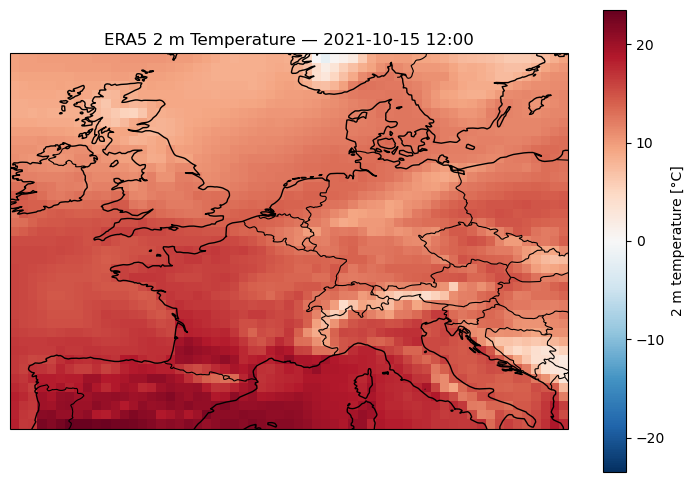

In [7]:
### visualise a variable, e.g. 

temperature = (
    ds_merged["2t"]
    .sel(forecast_reference_time="2021-10-15T12:00")
    - 273.15
)

fig = plt.figure(figsize=(9, 6))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

temperature.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    cbar_kwargs={"label": "2 m temperature [°C]"},
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS,linewidth=0.8)

ax.set_title("ERA5 2 m Temperature — 2021-10-15 12:00")

plt.show()